**CUSTOMER CHURN PREDICTION FOR SYRIATEL**


1.0 **Overview**


Syriatel, a telecommunications company, faces a challenge of customer churn. Churn occurs when subscribers leave a service provider, which directly impacts the company's revenue and competitiveness. This project aims to build a machine learning classifier model to identify and predict customers who are likely to churn before they actually do. Such predictive ability allows SyriaTel to act proactively by applying preventive retention strategies-for example, offering targeted promotions, improving customer service, or addressing customer pain points promptly. The ultimate goal is to reduce customer churn, retain valuable customers and strengthen loyalty, which in turn improves customer satisfaction and helps SyriaTel maintain a stronger position in the telecommunications market.



1.1 **Stakeholders**

The primary stakeholders of this project are: 
SyriaTel's business management team, customer excellence and retention departments,marketing departments and strategy team. These are the teams interested in reducing customer churn and improving customer loyalty. 



2.0 **Business Understanding**

Customer churn poses a significant revenue-risk for SyriaTel and would want to reduce the churn by identifying the customers at risk early enough.There is need for a data-driven method to do the following:

Predict the customers most likely to churn.

Understand the key factors driving customer dissatisfaction.

Determine the estimated revenue at risk from customers who churn.

Recommend actionable retention strategies.






2.1 **Business Objectives and Questions**



What is the estimated revenue at risk

Churn patterns

Which classification model can accurately be used to predict customer churn.

Which triggers are strongly associated with customer churn.

Practical Recommendations and isnights from the analysis and model outcomes.




2.2 **Metrics For Success**

Accuracy: Often reported between 70% to 90% depending on the model and dataset.

Precision: Usually ranges from 60% to 85%, indicating the proportion of correctly predicted churners.

Recall: Commonly falls between 50% to 80%, reflecting the model's ability to identify actual churners.

F1 Score: Typically reported around 0.6 to 0.8, balancing precision and recall.

ROC-AUC Score: Often ranges from 0.7 to 0.9, showing the model's discrimination ability.

Confusion Matrix Values: Specific counts of true positives, false positives, true negatives, and false negatives are usually provided, but exact numbers vary by study.

3.0 **Data Understanding**

The dataset was from Kaggle. It provides an in-depth view of various aspects of customer behaviour and characteristics within SyriaTel, a telecommunications company. It contains subscriber demographics, service plans, usage patterns,billings charges and customer support interactions which are key indicators of customer churn and for building predictive models. 

The dataset contains 21 features (columns) and 3333 customer records(rows).


3.1 **Target**

The target variable is 'Churn'  which indicates whether a customer has discontinued service with the company.

True  - Customer is likely to leave the service.

False  - Customer is likely to remain.

This is a binary classification problem.

3.2 **Data Preparation**

The main focus here is to ensure that the dataset is clean and reliable for further indepth analysis. It entails checking for missing values, duplicates and outliers.


3.3 **Importing the necessary libraries**

In [1]:
# Libraries for data loading, cleaning and exploratory data analysis

import pandas as pd
import numpy as np
from scipy import stats

In [2]:
# Libraries for data pre-processing (Encoding and Scaling)
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
# Visualization Libraries
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
# Libraries for data modelling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LassoCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

In [5]:
# Feature selection
from sklearn.feature_selection import RFE, RFECV


In [6]:
# For model Evaluation
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,auc

In [7]:
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score

In [8]:
# Loading the dataset as saving it as customerdata_df and calling the first 5 rows

customerdata_df = pd.read_csv('bigml_59c28831336c6604c800002a.csv')
customerdata_df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [9]:
# Checking the structure and Handling the missing values
customerdata_df.info()
customerdata_df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

(3333, 21)

3.4 **Handling the missing values and duplicates**

In [10]:
#Checking the missing values and duplicates
customerdata_df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [11]:
customerdata_df.duplicated().sum()

0

In [12]:
customerdata_df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In this dataset there are no missing values and no dulpicates as well.

**Feature Categories**

a.**Customer Usage** 

These features capture how customers use the service.
total day minutes – total daytime call duration

total day calls – total number of calls made during the day

total day charge – total charges for daytime calls

total eve minutes – total evening call duration

total eve calls – total number of calls made in the evening

total eve charge – total charges for evening calls

total night minutes – total night call duration

total night calls – total number of calls made at night

total night charge – total charges for night calls

total intl minutes – total international call duration

total intl calls – total number of international calls

total intl charge – total charges for international calls


b. **Service Plans**

These features describe the type of services customers subscribe to.
international plan – whether the customer has an international calling plan

voice mail plan – whether voicemail plan is subscribed

number of voice mail messages

c. ** Customer Support**

This is often a strong indicator of dissatisfaction, as customers typically contact customer service when they experience problems with the service.
number of customer service calls

d. **Administrative Features**

state – the state/region where the customer lives

account length – time (in days) the customer has had the account

area code – geographic telephone area code

e. **Identifiers**

Unique identifier (to be excluded from modelling)
customer phone number

3.5 **Dropping the non-predictive columns**

Phone number is an identifier and may not add value as it has no significance as a predictor.

In [13]:
# Dropping the non-predictive columns and confirming the phone number has been dropped
customerdata_df.drop(columns =['phone number'],inplace=True)
print(customerdata_df.columns)

Index(['state', 'account length', 'area code', 'international plan',
       'voice mail plan', 'number vmail messages', 'total day minutes',
       'total day calls', 'total day charge', 'total eve minutes',
       'total eve calls', 'total eve charge', 'total night minutes',
       'total night calls', 'total night charge', 'total intl minutes',
       'total intl calls', 'total intl charge', 'customer service calls',
       'churn'],
      dtype='object')


4.0 **Exploratory Data Analysis and Visualization**

In [14]:
customerdata_df.describe

<bound method NDFrame.describe of      state  account length  area code international plan voice mail plan  \
0       KS             128        415                 no             yes   
1       OH             107        415                 no             yes   
2       NJ             137        415                 no              no   
3       OH              84        408                yes              no   
4       OK              75        415                yes              no   
...    ...             ...        ...                ...             ...   
3328    AZ             192        415                 no             yes   
3329    WV              68        415                 no              no   
3330    RI              28        510                 no              no   
3331    CT             184        510                yes              no   
3332    TN              74        415                 no             yes   

      number vmail messages  total day minutes  total

4.1 **Numerical columns**

This will give a global summary of each numerical feature.

In [15]:
# Selecting numerical columns irrespective of whether the customer churn or not

numerical_customerdata_df = customerdata_df.select_dtypes(include=['float64','int64'])

In [16]:
for col in numerical_customerdata_df.columns:
    mean_val = numerical_customerdata_df[col].mean()
    std_val= numerical_customerdata_df[col].std()
    print(f"{col}: mean = {mean_val:.2f}, std_dev =val {std_val:2f}")


account length: mean = 101.06, std_dev =val 39.822106
area code: mean = 437.18, std_dev =val 42.371290
number vmail messages: mean = 8.10, std_dev =val 13.688365
total day minutes: mean = 179.78, std_dev =val 54.467389
total day calls: mean = 100.44, std_dev =val 20.069084
total day charge: mean = 30.56, std_dev =val 9.259435
total eve minutes: mean = 200.98, std_dev =val 50.713844
total eve calls: mean = 100.11, std_dev =val 19.922625
total eve charge: mean = 17.08, std_dev =val 4.310668
total night minutes: mean = 200.87, std_dev =val 50.573847
total night calls: mean = 100.11, std_dev =val 19.568609
total night charge: mean = 9.04, std_dev =val 2.275873
total intl minutes: mean = 10.24, std_dev =val 2.791840
total intl calls: mean = 4.48, std_dev =val 2.461214
total intl charge: mean = 2.76, std_dev =val 0.753773
customer service calls: mean = 1.56, std_dev =val 1.315491


<function matplotlib.pyplot.show(close=None, block=None)>

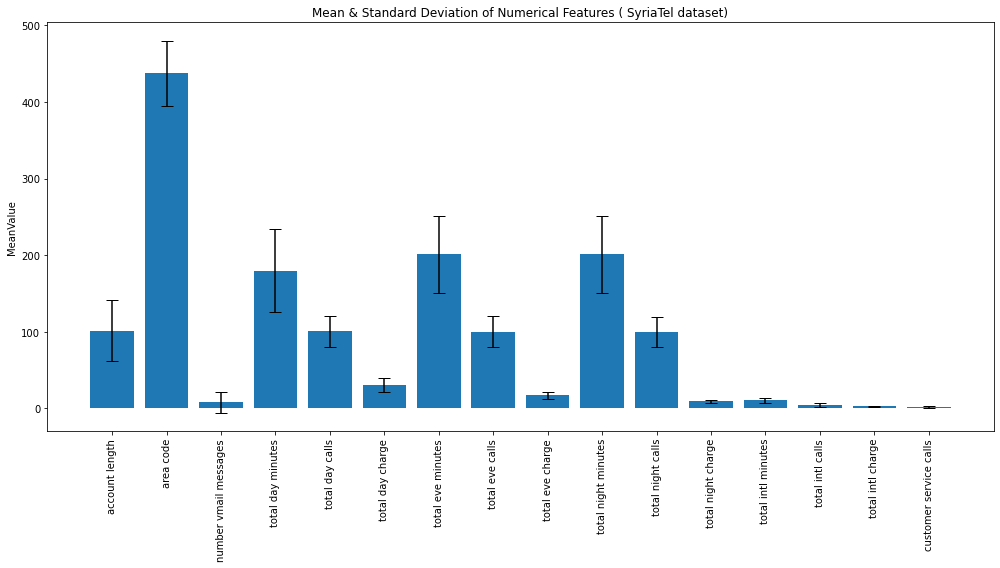

In [17]:
means = numerical_customerdata_df.mean()
stds =  numerical_customerdata_df.std()

plt.figure(figsize=(14,8))
plt.bar(numerical_customerdata_df.columns,means,yerr=stds,capsize=6)
plt.xticks(rotation=90)
plt.ylabel("MeanValue")
plt.title("Mean & Standard Deviation of Numerical Features ( SyriaTel dataset)")
plt.tight_layout()
plt.show

In [18]:
# Summary on Global categorical features
categorical_customerdata_df = customerdata_df.select_dtypes(include=['object'])

categorical_customerdata_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   state               3333 non-null   object
 1   international plan  3333 non-null   object
 2   voice mail plan     3333 non-null   object
dtypes: object(3)
memory usage: 78.2+ KB


Distribution of value counts of the 3 objects features


In [19]:
# 10 Most Common states
categorical_customerdata_df['state'].value_counts().head(10)

WV    106
MN     84
NY     83
AL     80
OH     78
WI     78
OR     78
WY     77
VA     77
CT     74
Name: state, dtype: int64

In [20]:
# Value count for international plan

categorical_customerdata_df['international plan'].value_counts()

no     3010
yes     323
Name: international plan, dtype: int64

In [21]:
# Value count for voice mail plan

categorical_customerdata_df['voice mail plan'].value_counts() 

no     2411
yes     922
Name: voice mail plan, dtype: int64

Overall summary of the global categorical features
The most common states were: WV, MN, NY, AL, WI, OH, OR, VA, WY, CT.

Most customers did not have international plan (3010 versus 323).

Most customers did not have a voice mail plan (2411 vs 922).

On the three global categorical features the summary is as follows;

The most common state were : WV,MN,NY,AL,WI,OH,OR,VA,WY,CT.

Most customers did not have international plan that is 3010 against 323.

Most customers did not have a voice mail plan ( 2411 vs 922).




Separating the customers who churned and those who did not

In [22]:
# Creating a variable 'churned_customer' which contains all customers who churned and 'not_churned_customers' for those who did not churn

churned_customers = customerdata_df.loc[customerdata_df['churn']==1]
non_churned_customers =customerdata_df.loc[customerdata_df['churn']==0]
len(churned_customers),len(non_churned_customers)


(483, 2850)

There were 483 customer who churned against 2850 who did not

In [23]:
# Creating new variables with only numerical information in both groups
churned_numerical_customers_df =churned_customers.select_dtypes(include = ['float64', 'int64'])
non_churned_numerical_customers_df =non_churned_customers.select_dtypes(include = ['float64', 'int64'])
churned_numerical_customers_df,non_churned_numerical_customers_df


(      account length  area code  number vmail messages  total day minutes  \
 10                65        415                      0              129.1   
 15               161        415                      0              332.9   
 21                77        408                      0               62.4   
 33                12        408                      0              249.6   
 41               135        408                     41              173.1   
 ...              ...        ...                    ...                ...   
 3301              84        415                      0              280.0   
 3304              71        510                      0              186.1   
 3320             122        510                      0              140.0   
 3322              62        408                      0              321.1   
 3323             117        415                      0              118.4   
 
       total day calls  total day charge  total eve minutes  t

In [24]:
# Standard deviation for the churned numerical features

for numerical_column in churned_numerical_customers_df.columns:
    print (f'This is the mean and standard deviation of the {numerical_column}:{churned_numerical_customers_df[numerical_column].mean()}+/- {churned_numerical_customers_df[numerical_column].std()}')

This is the mean and standard deviation of the account length:102.66459627329192+/- 39.46782040739152
This is the mean and standard deviation of the area code:437.8178053830228+/- 42.792269798525105
This is the mean and standard deviation of the number vmail messages:5.115942028985507+/- 11.860138199216575
This is the mean and standard deviation of the total day minutes:206.91407867494823+/- 68.99779153758718
This is the mean and standard deviation of the total day calls:101.33540372670808+/- 21.58230721307551
This is the mean and standard deviation of the total day charge:35.17592132505176+/- 11.729709881783515
This is the mean and standard deviation of the total eve minutes:212.41014492753624+/- 51.72890955344904
This is the mean and standard deviation of the total eve calls:100.56107660455487+/- 19.72471059273491
This is the mean and standard deviation of the total eve charge:18.05496894409938+/- 4.396762264655277
This is the mean and standard deviation of the total night minutes:20

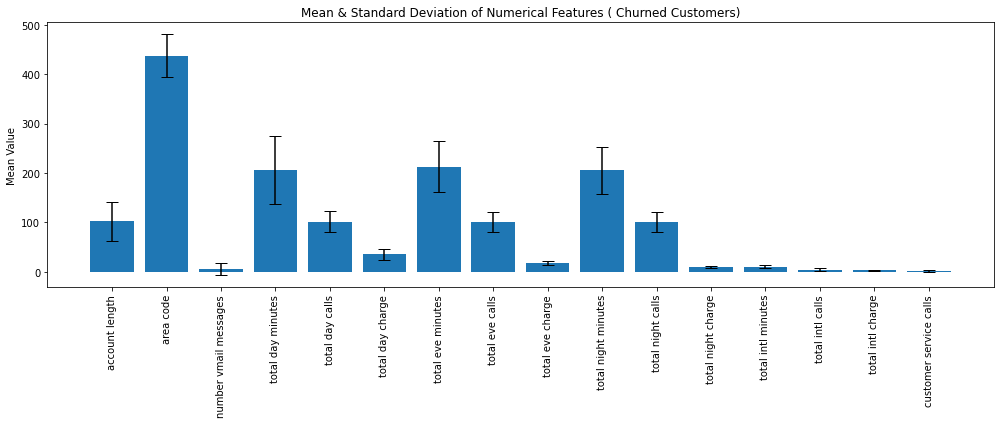

In [25]:
# Calculating  mean and standard deviation
means = churned_numerical_customers_df.mean()
stds = churned_numerical_customers_df.std()
features = means.index

x = np.arange(len(features))
plt.figure(figsize= (14,6))
plt.bar(x, means,yerr =stds, capsize=6)
plt.xticks(x,features,rotation =90)
plt.ylabel("Mean Value")
plt.title("Mean & Standard Deviation of Numerical Features ( Churned Customers)")
plt.tight_layout()
plt.show()


**Objective 1. Estimating the potential revenue risk when customers churn.**

From the above output,the following were the average customer charges in the Churn group:

Total day charge = 35.17

Total evening charge = 18.05

total nighr charge = 9.23

Total international charge = 2.88

Total = 65.33 USD 

Since there were 483 customers who churned, this brings the total loss to 31,554.39 USD over 9 months (Time frame within which the data was collected)



Non - churned group.

In [26]:
 # Mean and Standard deviation for the non churned numerical features

for numerical_column in non_churned_numerical_customers_df.columns:
    print (f'This is the mean and standard deviation of the {numerical_column}:{non_churned_numerical_customers_df[numerical_column].mean()}+/- {non_churned_numerical_customers_df[numerical_column].std()}')

This is the mean and standard deviation of the account length:100.79368421052632+/- 39.88235017521783
This is the mean and standard deviation of the area code:437.07473684210527+/- 42.30615604448498
This is the mean and standard deviation of the number vmail messages:8.604561403508772+/- 13.913125391563675
This is the mean and standard deviation of the total day minutes:175.1757543859649+/- 50.18165518287504
This is the mean and standard deviation of the total day calls:100.28315789473685+/- 19.801156951805293
This is the mean and standard deviation of the total day charge:29.780421052631578+/- 8.530835463259525
This is the mean and standard deviation of the total eve minutes:199.043298245614+/- 50.292174620000246
This is the mean and standard deviation of the total eve calls:100.03859649122808+/- 19.958413717721953
This is the mean and standard deviation of the total eve charge:16.918908771929825+/- 4.274862704573758
This is the mean and standard deviation of the total night minutes:2

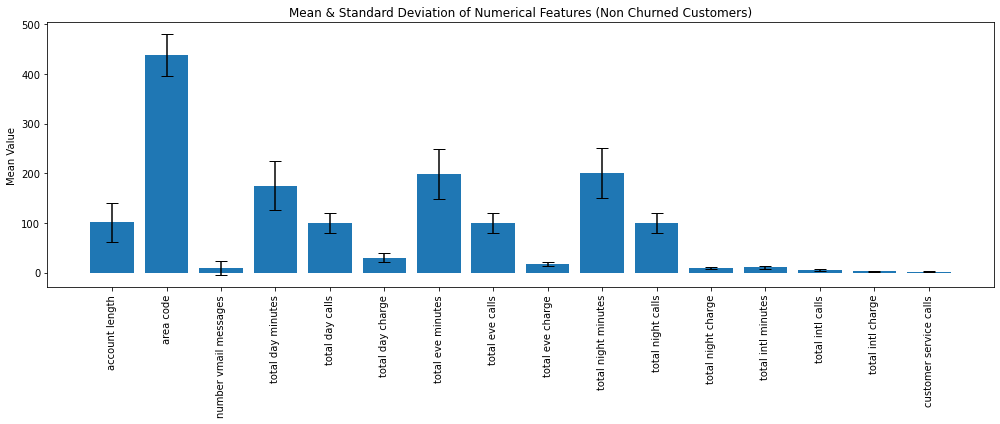

In [27]:
# Calculating  mean and standard deviation for non churned customers
means = non_churned_numerical_customers_df.mean()
stds = non_churned_numerical_customers_df.std()
features = means.index

x = np.arange(len(features))
plt.figure(figsize= (14,6))
plt.bar(x, means,yerr =stds, capsize=6)
plt.xticks(x,features,rotation =90)
plt.ylabel("Mean Value")
plt.title("Mean & Standard Deviation of Numerical Features (Non Churned Customers)")
plt.tight_layout()
plt.show()

Ascertaining if there are any statistical significant differences in the numerical features between the two groups.


In [28]:

# A/B Testing

# Are there any significant difference between those who churn and those who did not on numerical features
# Null hypothesis: There is no difference between the groups.
# Alternate hypothesis: There is difference between the groups.
# Set value of alpha = 0.05
from scipy.stats import ttest_ind

def ttest_churn(df, numerical_columns, churn_column='churn', alpha=0.05):
    """ 
    Performs Welch's t-test for each numerical column comparing churned vs non-churned customers.
    
    Parameters:
    - df: pandas DataFrame
    - numerical_columns: list of numerical column names
    - churn_column: name of the churn indicator column (0/1)
    - alpha: significance level (default 0.05)
    
    Returns:
    - results_df: DataFrame with t-statistic, p-value, and significance flag
    """
    results = []
    
    churned = df[df[churn_column] == 1]
    retained = df[df[churn_column] == 0]
    
    for col in numerical_columns:
        if col not in df.columns:
            continue
        
        # Welch’s t-test (equal_var=False)
        t_stat, p_val = ttest_ind(churned[col], retained[col], equal_var=False, nan_policy='omit')
        
        results.append({
            'Feature': col,
            't_statistic': t_stat,
            'p_value': p_val,
            'Significant': p_val < alpha
        })
    
    results_df = pd.DataFrame(results)
    return results_df

In [29]:
# Let us call our new function
numerical_cols = numerical_customerdata_df.columns.tolist()  # this contains only the numerical columns of both those who churned and those who did not.
ttest_results = ttest_churn(customerdata_df, numerical_cols)

# View results
print(ttest_results)

                   Feature  t_statistic       p_value  Significant
0           account length     0.961889  3.364575e-01        False
1                area code     0.353471  7.238496e-01        False
2    number vmail messages    -5.821254  8.764782e-09         True
3        total day minutes     9.684563  1.218968e-20         True
4          total day calls     1.002387  3.165434e-01        False
5         total day charge     9.684476  1.219876e-20         True
6        total eve minutes     5.272354  1.839080e-07         True
7          total eve calls     0.537389  5.911801e-01        False
8         total eve charge     5.271986  1.842608e-07         True
9      total night minutes     2.170889  3.028049e-02         True
10       total night calls     0.348818  7.273389e-01        False
11      total night charge     2.171007  3.027154e-02         True
12      total intl minutes     3.938851  9.065715e-05         True
13        total intl calls    -2.960420  3.185777e-03         

Summary findings of the Numerical Dataset between those who churned and those who did not.

For churned vs non_churned, the following features did not reveal statistical significant differences between the 2 groups 

a. Account length - 103.6, 100.7

b. Area Code - 437.8, 437.1

c. Total day calls - 101.3, 100.2

d. Total eve calls - 100.5, 100.0

e. Total night calls - 100.3, 100.1


The following features revealed statistically significant differences between the 2 groups (churned vs non_churned): -

a. Number of voice mail - 5.11, 8.6

b. Total day minutes - 206.9, 175.2

c. Total day charge - 35.1, 29.8

d. Total evening minutes - 212.4, 199.0

e. Total evening charge - 18.05, 16.9

f. Total night minutes - 205.2, 200.1

g. Total night charge - 9.2, 9.00

h. Total international minutes - 10.7, 10.2

g. Total international calls - 4.2, 4.5

h. Total international charge - 2.8, 2.7

i. Customer service calls - 2.2, 1.4

Value counts of the categorical summary statistics between the two groups

Objective 2 : **Churn Patterns**

**Churned group**

In [30]:
churned_categorical_customer_df = churned_customers.select_dtypes(include=['object'])
non_churned_categorical_customer_df = non_churned_customers.select_dtypes(include=['object'])

#State distribution in the churn group

churned_categorical_customer_df['state'].value_counts().head(10)

NJ    18
TX    18
MD    17
MI    16
NY    15
MN    15
MS    14
NV    14
MT    14
WA    14
Name: state, dtype: int64

**Non Churned group**

In [31]:
non_churned_categorical_customer_df['state'].value_counts().head(10)

WV    96
AL    72
VA    72
WI    71
MN    69
OH    68
WY    68
NY    68
OR    67
VT    65
Name: state, dtype: int64

In [32]:
# Top 10 states by count

churned_top_states =churned_categorical_customer_df['state'].value_counts().head(10)
non_churned_top_states =non_churned_categorical_customer_df['state'].value_counts().head(10)

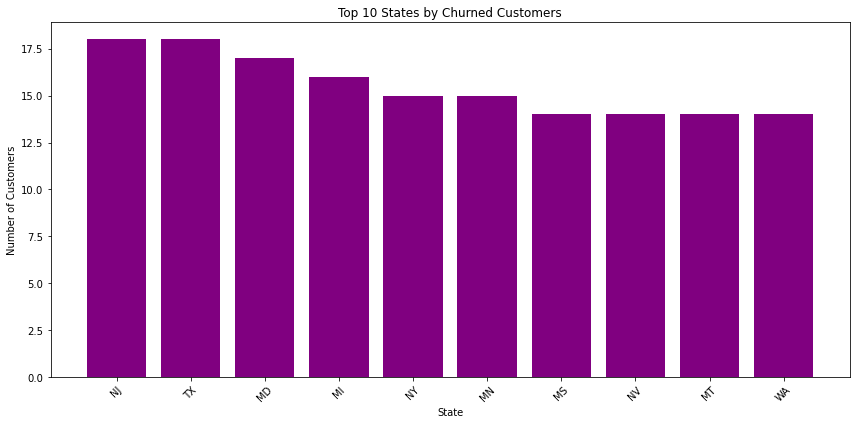

In [33]:
# Plot 1. Churned churned_customers

fig1, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(churned_top_states.index, churned_top_states.values, color='purple')
ax1.set_title('Top 10 States by Churned Customers')
ax1.set_xlabel('State')
ax1.set_ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



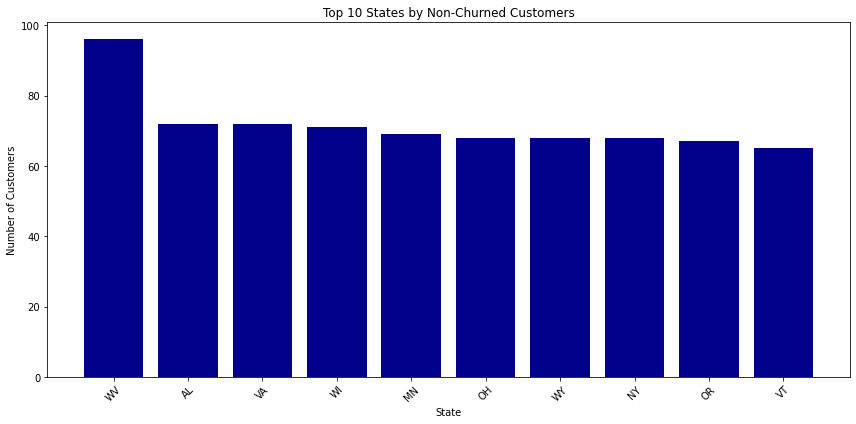

In [34]:

# Plot 2: Non-Churned Customers

fig2, ax2 = plt.subplots(figsize=(12,6))
ax2.bar(non_churned_top_states.index, non_churned_top_states.values, color='darkblue')
ax2.set_title('Top 10 States by Non-Churned Customers')
ax2.set_xlabel('State')
ax2.set_ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


value counts for 'international plan'

churned_categorical_customer_df['international plan'].value_counts(), non_churned_categorical_customers_df['international plan'].value_counts()

In [35]:
# Value counts for internation plan
churned_categorical_customer_df['international plan'].value_counts(), non_churned_categorical_customer_df['international plan'].value_counts()

(no     346
 yes    137
 Name: international plan, dtype: int64,
 no     2664
 yes     186
 Name: international plan, dtype: int64)

In [36]:
# Value counts for voice mail plan

churned_categorical_customer_df['voice mail plan'].value_counts(), non_churned_categorical_customer_df['voice mail plan'].value_counts()



(no     403
 yes     80
 Name: voice mail plan, dtype: int64,
 no     2008
 yes     842
 Name: voice mail plan, dtype: int64)

**Count Categories**

In [37]:
churned_international = churned_categorical_customer_df['international plan'].value_counts()
non_churned_international = non_churned_categorical_customer_df['international plan'].value_counts()

churned_voicemail = churned_categorical_customer_df['voice mail plan'].value_counts()
non_churned_voicemail = non_churned_categorical_customer_df['voice mail plan'].value_counts()

international_index = churned_international.index
voicemail_index = churned_voicemail.index



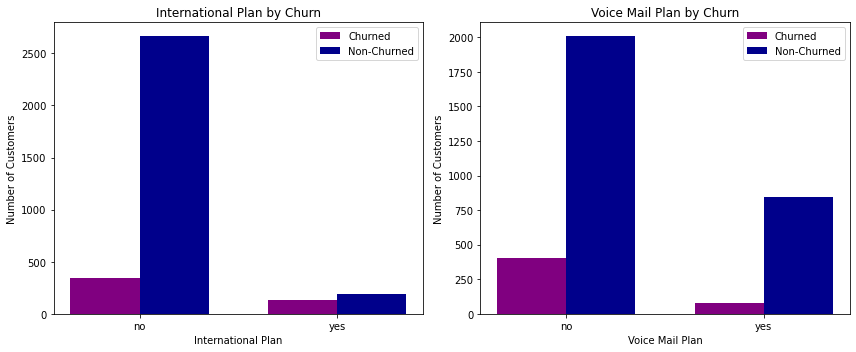

In [38]:
# Seting up a figure on churn count categories
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# International Plan
width = 0.35
x = range(len(international_index))

axes[0].bar(x, churned_international, width=width, label='Churned', color='purple')
axes[0].bar([i + width for i in x], non_churned_international, width=width, label='Non-Churned', color='darkblue')

axes[0].set_xticks([i + width/2 for i in x])
axes[0].set_xticklabels(international_index)
axes[0].set_title('International Plan by Churn')
axes[0].set_xlabel('International Plan')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Voice Mail Plan
x = range(len(voicemail_index))
axes[1].bar(x, churned_voicemail, width=width, label='Churned', color='purple')
axes[1].bar([i + width for i in x], non_churned_voicemail, width=width, label='Non-Churned', color='darkblue')

axes[1].set_xticks([i + width/2 for i in x])
axes[1].set_xticklabels(voicemail_index)
axes[1].set_title('Voice Mail Plan by Churn')
axes[1].set_xlabel('Voice Mail Plan')
axes[1].set_ylabel('Number of Customers')
axes[1].legend()

plt.tight_layout()
plt.show()



**Findings**

The Churned customers were primarily from TX, NJ, MD, MI, MN.while the Non-churned customers were mainly from WV, VA, AL, WI, MN.

International plan:
Most of the customers in both groups did not have an international plan.

Churned:   346 without vs 137 with plan.

Non-churned: 2664 without vs 186 with plan.

Voicemail plan:
Similarly, most customers in both groups did not have a voicemail plan.

Churned: 403 without vs 80 with plan

Non-churned: 2008 without vs 842 with plan

Consequence of the Categorical Comparison
Even though the patterns for international plan and voicemail plan were similar across churned and non-churned customers, we opt to retain these features in our model since they can still be predictive of churn.

5.0 **Data Modelling**

5.1 **Preparing data for modeling**

We now prepare the data for modeling by One Hot Encoding the Categorical Fetaures and scaling the numerical features using Standard Scaler. we scale the numerical features because they are all measured in different units,have different ranges, means and variances.


In [39]:
# Spliting the Data intp X and Y datasets
X = customerdata_df.drop('churn', axis= 1)
y = customerdata_df['churn']


X = customer_df.drop('churn', axis = 1)
y = customer_df['churn']

5.2 **Performing a Train/Test Split**

We use 70% of the data for training and 30% for testing. The stratify parameter ensures that the distribution of the target variable churn is similar across both sets

In [40]:
# Train /Test Split

X_train,X_test,y_train,y_test =train_test_split(X,y,test_size = 0.3, random_state= 42)

In [41]:
# Checking the shapes of the split data
print("Train set size:",X_train.shape )
print("Test set size:",X_test.shape )

Train set size: (2333, 19)
Test set size: (1000, 19)


In [42]:
#Separation of categorical and numerical features in the training and testing datasets
X_train_categorical =X_train.select_dtypes(exclude = ["int64","float64"])
X_train_numerical = X_train.select_dtypes(include = ["int64","float64"])

X_test_categorical =X_test.select_dtypes(exclude = ["int64","float64"])
X_test_numerical = X_test.select_dtypes(include = ["int64","float64"])


In [43]:
# One Hot Encode the categorical features

X_train_categorical_transformed = X_train_categorical.copy()
X_test_categorical_transformed = X_test_categorical.copy()

In [44]:
# Instantiate the One Hot Encoder

ohe = OneHotEncoder(drop ='first',sparse =False)

# Fit the ohe to X_train the transform

ohe.fit(X_train_categorical)
X_train_ohe =pd.DataFrame(
    ohe.transform(X_train_categorical),
    index = X_train_categorical.index,
    columns=ohe.get_feature_names(X_train_categorical.columns))

In [45]:
# Transforming the X_test only to prevent data leakage

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_categorical),
    index=X_test_categorical.index,
    columns=ohe.get_feature_names(X_train_categorical.columns))

In [46]:
# Scaling the numerical data
scaler = StandardScaler() #Instantiating the standard scaler

In [47]:
#Fitting the scaler to X_train then transforming

scaler.fit(X_train_numerical)
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_numerical),
   index = X_train_numerical.index, # Index ensure we can concatenate with other columns
    columns=X_test_numerical.columns)


In [48]:
# Transform X_test

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_numerical),
    index = X_test_numerical.index,
    columns =X_test_numerical.columns)

5.3 **Merge the datasets back to form one full dataset**


In [49]:
# Concatenate the categorical and numeric X_train

X_train_full = pd.concat([X_train_scaled, X_train_ohe],axis=1)

In [50]:
# Concatenate the categorical and numeric X_test
X_test_full = pd.concat([X_test_scaled, X_test_ohe],axis=1)

In [51]:
# Confirming the shapes and columns

print(X_train_full.shape, X_test_full.shape)
print (X_train_full.columns,X_test_full.columns)

(2333, 68) (1000, 68)
Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'state_AL', 'state_AR', 'state_AZ',
       'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL',
       'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN',
       'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME',
       'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC',
       'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI',
       'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_VA',
       'state_VT

5.4 **Building and Evaluating a Baseline Model using Logistic Regression**

Here, we are going to build a logistic regression model.
This model is fast, simple and easy to interpret the features on probability.
It assumes a linear relationship between the variables.

In [52]:
# Instantiate the model

LR = LogisticRegression()

In [53]:
# Fit the X_train_full (the scaled and the encoded versions of X_train and y_train) to the model
LR.fit(X_train_full,y_train)

LogisticRegression()

In [54]:
# Make predictions on X_test_full

y_lr_preds = LR.predict(X_test_full)

In [55]:
# Probability predictions to use in calculating ROC,AUC

y_lr_preds_proba= LR.predict_log_proba(X_test_full)[:,1]

5.5 **Creating a model Using Decision Tree Classifier**

This model captures non-linear relationships and feature interactions easily.
It handles categorical and numerical features without scaling,though in our case,we scaled the numerical variables.
The model can capture complex patterns in datasets and has intuitive graphical 

In [56]:
# Instantiate the model
DC =DecisionTreeClassifier(criterion = 'entropy')


In [57]:
# Fit the data to the model
DC.fit(X_train_full,y_train)

DecisionTreeClassifier(criterion='entropy')

In [58]:
# Make predictions on the X_test_full
y_dc_preds =DC.predict(X_test_full)

In [59]:

# Make probability predictions to use in calculating ROC,AUC
y_dc_preds_proba= DC.predict_proba(X_test_full)[:,1]

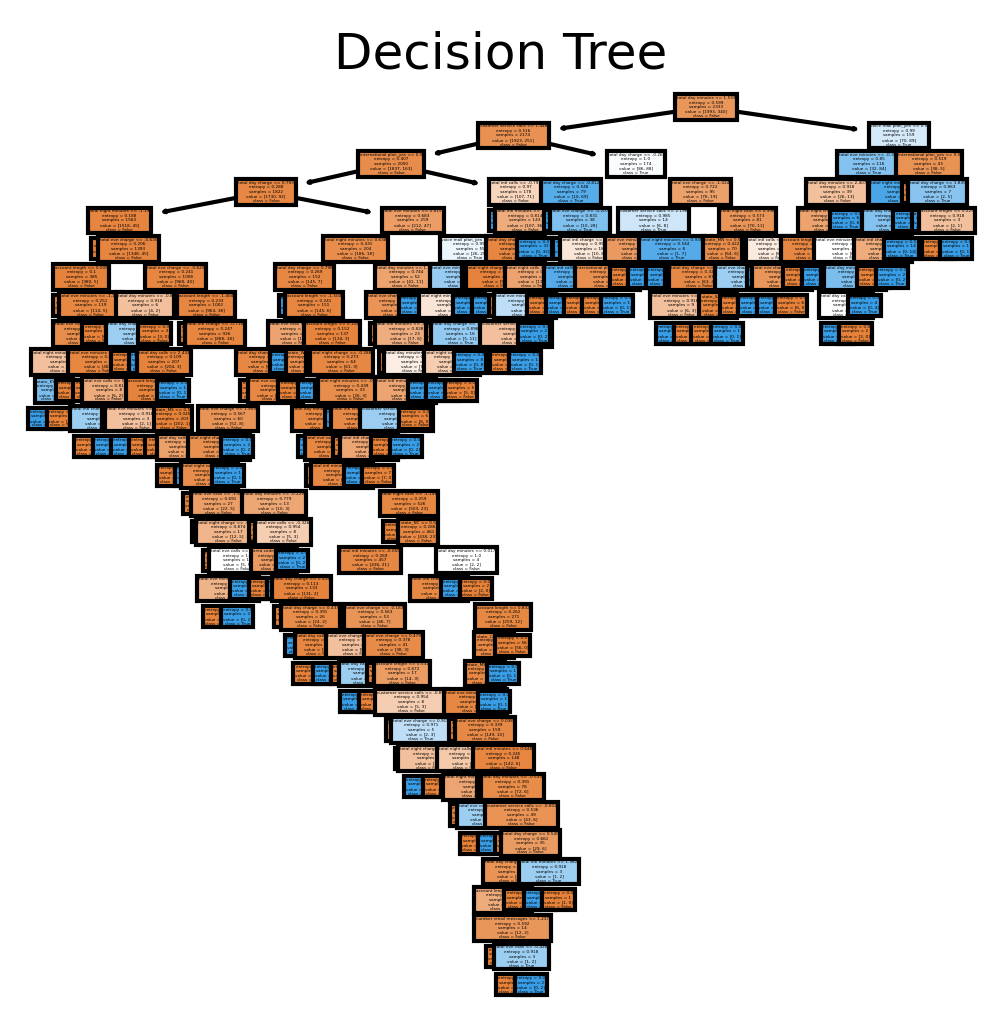

In [60]:
# Plotting a decision tree

fig,axes = plt.subplots(nrows=1, figsize = (4,4),dpi= 300)
tree.plot_tree(DC,
               feature_names= X_train_full.columns,
               class_names=np.unique(y).astype(str),
               filled = True)
plt.title('Decision Tree')
plt.show()

5.6 **Creating a Model using Random Forest Classifier**

Here we will create a model that improves accuracy and stability over the decision trees. It reduces overfitting from individual trees.This model is robust to noise,can handle high dimensional data like OHE features and can estimate feature importance.

In [61]:
# Instantiate the RandomForest model
RF = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

In [62]:
# Fit the data to the model
RF.fit(X_train_full,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [63]:
# Predict on X_test_full
y_rf_preds =RF.predict(X_test_full)

In [64]:
# Make probability predictions to use in calculating ROC, AUC
y_rf_preds_proba = RF.predict_proba(X_test_full)[:,1]

6.0 **Evaluation and Predictive Findings**

We will evaluate using the following:

A- Accuracy 

B- ROC and AUC 

6.1 **Accuracy**

We will evaluate the accuracy of predicting the training and the testing tests to determine overfitting and underfitting of the 3 models. This method is however not reliable for imbalanced classes thus the need to include ROC.

In [65]:
# Comparing the training accuracy vs the testing accuracy to determine of over and under fitting

# For Logistic Regression
y_lr_pred_train =LR.predict(X_train_full)

# For Decision Tree Classifier
y_dc_pred_train = DC.predict(X_train_full)

#For Random Forest Classifier
y_rf_pred_train =RF.predict(X_train_full)


In [66]:
# Assessing accuracy of the 3 models using a function
def evaluate_predictions(y_true,y_pred,model_name ="Model"):
    """ 
    Evaluate a classification model using existing predictions.

    Parameters:
    - y_true: array-like,true labels
    - model_name: str,optional name of the model
    Prints accuracy, confusion matrix, classification report
    """
    print(f"==={model_name} Evaluation===")
    print("Accuracy:", round(accuracy_score(y_true,y_pred),4))

**Evaluate the Models Using the Function**

In [67]:
# Logistic Regression
evaluate_predictions(y_test,y_lr_preds, model_name =LR)

#Decision Tree
evaluate_predictions(y_test,y_dc_preds, model_name = DC)

# Random Forest
evaluate_predictions(y_test,y_rf_preds, model_name =RF)

===LogisticRegression() Evaluation===
Accuracy: 0.86
===DecisionTreeClassifier(criterion='entropy') Evaluation===
Accuracy: 0.911
===RandomForestClassifier(n_jobs=-1, random_state=42) Evaluation===
Accuracy: 0.939


In [68]:
# Develop a similar function for the training data
def evaluate_training_predictions(y_true_train,y_pred_train,model_name ="Model"):
    """ 
    Evaluate a classification model using training predictions.

    Parameters:
    - y_true_train: array-like,true labels for training set
    - model_name: str,optional name of the model
    Prints accuracy, confusion matrix, classification report
    """
    print(f"==={model_name} Training Evaluation===")
    print("Accuracy:", round(accuracy_score(y_true_train,y_pred_train),4))

**Evaluating the Model on the the Training Data**

In [69]:
# Logistic Regression
evaluate_training_predictions(y_train,y_lr_pred_train, model_name =LR)

#Decision Tree
evaluate_training_predictions(y_train,y_dc_pred_train, model_name = DC)

# Random Forest
evaluate_training_predictions(y_train,y_rf_pred_train, model_name =RF)

===LogisticRegression() Training Evaluation===
Accuracy: 0.8706
===DecisionTreeClassifier(criterion='entropy') Training Evaluation===
Accuracy: 1.0
===RandomForestClassifier(n_jobs=-1, random_state=42) Training Evaluation===
Accuracy: 1.0


** Objective 3: **Best Classification Model to Predict Customer Churn**

The Logistic regression model correctly classified about 87% of the training samples which means it is learning the patterns but not memorizing.

The Decision Tree and the Random forest models classified 100% of the training samples. These two models are likely to overfit.

6.2 **ROC/AUC**




In [70]:
# For logistic Regression
lr_fpr,lr_tpr,lr_thresholds = roc_curve(y_test, y_lr_preds_proba)

# For Decision  Tree Classifier
dc_fpr,dc_tpr,dc_thresholds = roc_curve(y_test, y_dc_preds_proba)

# For Random Forest Classifier
rf_fpr,rf_tpr,rf_thresholds = roc_curve(y_test, y_rf_preds_proba)


In [71]:
# A function to delelop an ROC and AUC scores
def plot_roc_curve(fpr,tpr,thresholds =None, model_name='Model'):
    """ 
    Plot ROC curve and display AUC.

    Parameters:
    - fpr: array-like,false positive rates
    - tpr: array-like, true positive rates
    - thresholds: array-like,optional,classification thresholds
    - model_name: str,name of the model
    """
    # Calculate AUC
    roc_auc =auc(fpr,tpr)


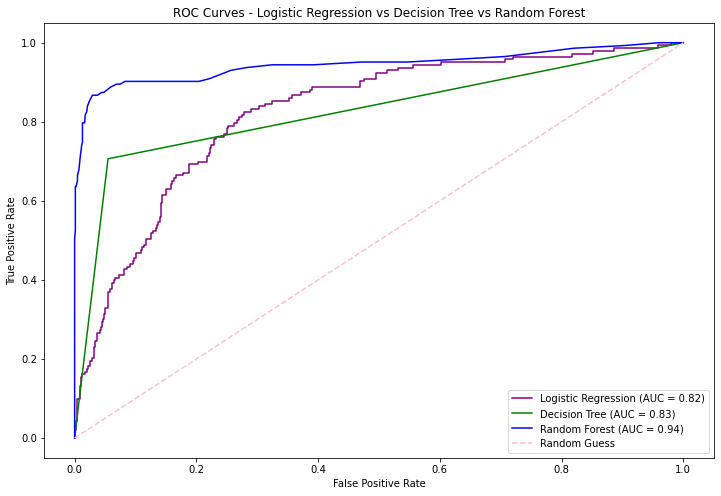

In [72]:
# Plot the ROC-AUC Curve
plt.figure(figsize =(12,8))
# Logistic Regression

# Logistic Regression
y_lr_proba = LR.predict_proba(X_test_full)[:,1]
fpr_lr, tpr_lr,_= roc_curve(y_test, y_lr_proba)

roc_auc_lr = roc_auc_score(y_test, y_lr_proba)
plt.plot(fpr_lr, tpr_lr, color='purple', label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Decision Tree
y_dc_proba = DC.predict_proba(X_test_full)[:,1]
fpr_dc, tpr_dc, _ = roc_curve(y_test, y_dc_proba)
roc_auc_dc = roc_auc_score(y_test, y_dc_proba)
plt.plot(fpr_dc, tpr_dc, color='green', label=f'Decision Tree (AUC = {roc_auc_dc:.2f})')

# Random Forest
y_rf_proba = RF.predict_proba(X_test_full)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_rf_proba)
roc_auc_rf = roc_auc_score(y_test, y_rf_proba)
plt.plot(fpr_rf, tpr_rf, color='blue', label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Random Guess line
plt.plot([0,1], [0,1], color='pink', linestyle='--', label='Random Guess')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Logistic Regression vs Decision Tree vs Random Forest')
plt.legend(loc='lower right')
plt.show()

Interpretation of the ROC and AUC scores

The Random Forest Classifier has the highest (0.93) AUC across the 3 models. This means the model is excellent in distinguishing churners from non churners. 

The Decision Tree Classifier is above the random line but below the Random Forest with an AUC of 0.82. This model correctly ranks positives vs negatives better than the Logistic Regression but is less robust than the Random Forest because a single tree can overfit.

The Logistic Regression with an AUC ofv0.82 is the lowest among the three. Implying that it performs reasonably well, but less capable of capturing complex non-linear patterns.

Interpretation: The ROC curve is above the random line but below Random Forest.

6.3 **Confusion Matrix**

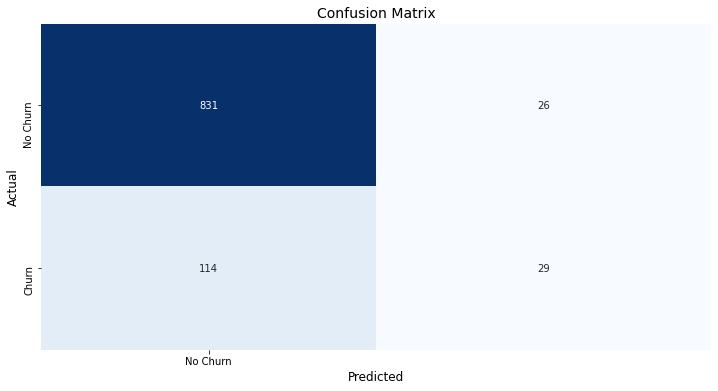

In [73]:
# Confusion Matrix
import seaborn as sns
conf_matrix = confusion_matrix(y_test,y_lr_preds)
plt.figure(figsize=(12,6))
sns.heatmap(conf_matrix,annot=True,fmt='d', cmap='Blues', xticklabels=['No Churn'], yticklabels=['No Churn', 'Churn'],cbar=False)
plt.xlabel('Predicted',fontsize=12)
plt.ylabel('Actual',fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()


Interpretation

True Negatives (TN): 831 - Correctly predicted "No Churn"

False Positive (FP): 26 Incorrectly predicted "Churn" when it was "No Churn"

False Negative(FN): 114 Missed actual "Churn" cases predicted as "No Churn"

True Positives (TP) : 29 Correctly predicted "Churn".

Observation: 

High  True Negatives (831) means it is good at spotting non churners but struggles to identify actual churners demonstrated by Low TP(29)

Many churners (114) are missed which is critical for retention efforts.



**Selecting the best Features for the Best Model**


We apply Embedded methods (Lasso)- L1 to our Logistic Regression


 6.4 **Feature Importance**

In [74]:
lr_l1 =LogisticRegression(penalty='l1', solver ='liblinear')
lr_l1.fit (X_train_full,y_train)
selected_features =X_train_full.columns[lr_l1.coef_[0] !=0]
print(selected_features)

Index(['account length', 'area code', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total intl calls',
       'total intl charge', 'customer service calls', 'state_AL', 'state_AR',
       'state_AZ', 'state_CA', 'state_CO', 'state_DC', 'state_DE', 'state_GA',
       'state_HI', 'state_IA', 'state_IL', 'state_KS', 'state_KY', 'state_LA',
       'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS',
       'state_MT', 'state_NC', 'state_ND', 'state_NJ', 'state_NM', 'state_NV',
       'state_NY', 'state_OR', 'state_PA', 'state_RI', 'state_SC', 'state_SD',
       'state_TN', 'state_TX', 'state_VA', 'state_VT', 'state_WA', 'state_WI',
       'state_WY', 'international plan_yes', 'voice mail plan_yes'],
      dtype='object')


In [75]:
# Working with 10 features
rfe = RFE (LogisticRegression(),n_features_to_select=10)
rfe.fit(X_train_full,y_train)
selected_features_2 =X_train_full.columns[rfe.support_]

print(selected_features_2)

print(selected_features_2)

Index(['state_AL', 'state_IA', 'state_IL', 'state_MT', 'state_ND', 'state_NJ',
       'state_SC', 'state_VT', 'international plan_yes',
       'voice mail plan_yes'],
      dtype='object')
Index(['state_AL', 'state_IA', 'state_IL', 'state_MT', 'state_ND', 'state_NJ',
       'state_SC', 'state_VT', 'international plan_yes',
       'voice mail plan_yes'],
      dtype='object')


In [76]:
# Comparison using the decision trees
# Get feature importance
feature_importances= pd.Series(DC.feature_importances_, index= X_test_full.columns)
feature_importances =feature_importances.sort_values(ascending=False)

print(feature_importances.head(10))


total day charge          0.136841
total day minutes         0.120702
customer service calls    0.107494
international plan_yes    0.098374
total eve minutes         0.089274
total intl minutes        0.084232
total eve charge          0.052819
total intl calls          0.048257
total night minutes       0.039478
voice mail plan_yes       0.037368
dtype: float64


In [77]:
# Random Forest Classifier
#This one select features automatically during training because each tree chooses splits that maximize information gain or reduce Gini Impurity.

# Get feature importances
feature_importances= pd.Series(RF.feature_importances_, index= X_test_full.columns)
feature_importances =feature_importances.sort_values(ascending=False)

print(feature_importances.head(10))

total day charge          0.127207
total day minutes         0.115827
customer service calls    0.105351
international plan_yes    0.069539
total eve charge          0.057186
total eve minutes         0.055551
total intl charge         0.042666
total intl minutes        0.042199
total night minutes       0.039255
total night charge        0.037807
dtype: float64


**Summary Findings on the Evaluations**


*Logistic Regression*:

The most influential features identified were the following states:
 AL, IL, ND, NJ, SC, TX, VA, VT, along with International Plan = Yes and Voice Mail Plan = Yes.

*Decision Tree Classifier*:

Key features included: total day charge, customer service calls, international plan_yes, total intl calls, total day minutes, total eve minutes, total eve charge, total intl charge, total night minutes, total night charge.

*Random Forest Classifier*:

The most important features were: total day charge, total day minutes, customer service calls, international plan_yes, total eve charge, total eve minutes, total intl charge, total intl minutes, total intl calls, total night charge.

7.0 **Model Tuning**

Hyperparameters of the three models can be tuned using techniques such as Grid Search to optimize the performance of the models.We tune the max_depth,min_samples_split and min_samples_leaf parameters


In [78]:
# 1. Logistic Regression
from sklearn.model_selection import GridSearchCV

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['liblinear', 'saga'],
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(estimator=lr,
                       param_grid=param_grid_lr,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1)

grid_lr.fit(X_train_full, y_train)

print("Best Parameters (Logistic Regression):", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)



Best Parameters (Logistic Regression): {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.8598285099852039


In [79]:
# 2.Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Define parameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with cross-validation
grid_dt = GridSearchCV(estimator=dt,
                       param_grid=param_grid_dt,
                       cv=5,            # 5-fold cross-validation
                       scoring='accuracy',
                       n_jobs=-1)

grid_dt.fit(X_train_full, y_train)

print("Best Parameters (Decision Tree):", grid_dt.best_params_)
print("Best CV Accuracy:", grid_dt.best_score_)

Best Parameters (Decision Tree): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Accuracy: 0.9391394252419332


In [80]:
# 3. Random Forest Classifier

rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators':[100,200,500],
    'max_depth': [None,10,20],
    'max_features':['auto', 'sqrt'],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid_rf = GridSearchCV(estimator=rf,
                       param_grid=param_grid_rf,
                       cv=5,
                       scoring='accuracy',
                       n_jobs=-1)
grid_rf.fit(X_train_full,y_train)
print("Best Parameters (Random Forest):", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)


Best Parameters (Random Forest): {'max_depth': 20, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9365569657479483


In [81]:
# Comparison of the 3 tuned models
# Collect results
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Best Parameters": [
        grid_lr.best_params_,
        grid_dt.best_params_,
        grid_rf.best_params_
    ],
    "Best CV Accuracy": [
        grid_lr.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_
    ]
}

# Convert to DataFrame for clean display
comparison_df = pd.DataFrame(results)
print(comparison_df)


                 Model                                    Best Parameters  \
0  Logistic Regression  {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}   
1        Decision Tree  {'criterion': 'gini', 'max_depth': 5, 'min_sam...   
2        Random Forest  {'max_depth': 20, 'max_features': 'auto', 'min...   

   Best CV Accuracy  
0          0.859829  
1          0.939139  
2          0.936557  


7.1 **Models comparison on extended performance metrics**

Here, we will use machine learning metrics of success such as Accuracy, Precision,Recall, F1 score and ROC_AUC to evaluate the performance of each model after training and tuning. This will help us choose the best model to use in reducing churn by identifying at-risk customers early.

In [82]:
# Define a helper function
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    
    return {
        "Model": name,
        "Best Parameters": model.get_params(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

# Evaluate tuned models
results = []
results.append(evaluate_model("Logistic Regression", grid_lr.best_estimator_, X_test_full, y_test))
results.append(evaluate_model("Decision Tree", grid_dt.best_estimator_, X_test_full, y_test))
results.append(evaluate_model("Random Forest", grid_rf.best_estimator_, X_test_full, y_test))

# Convert to DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model                                    Best Parameters  \
0  Logistic Regression  {'C': 10, 'class_weight': None, 'dual': False,...   
1        Decision Tree  {'ccp_alpha': 0.0, 'class_weight': None, 'crit...   
2        Random Forest  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...   

   Test Accuracy  Test Precision  Test Recall   Test F1  Test ROC-AUC  
0          0.863        0.550000     0.230769  0.325123      0.818337  
1          0.936        0.869159     0.650350  0.744000      0.907851  
2          0.940        1.000000     0.580420  0.734513      0.938617  


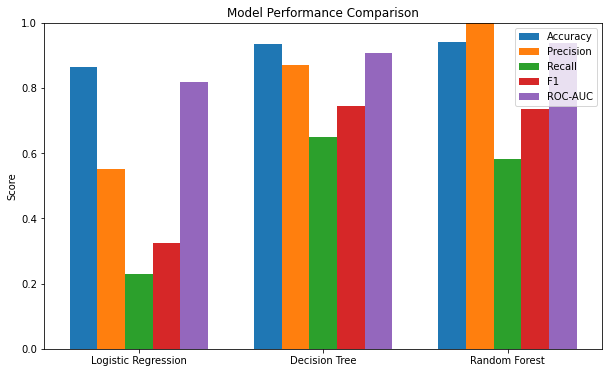

In [83]:
import pandas as pd
import matplotlib.pyplot as plt

# Original data
data = {
"Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
"Test Accuracy": [0.863, 0.936, 0.940],
"Test Precision": [0.55, 0.869159, 1.0],
"Test Recall": [0.230769, 0.650350, 0.580420],
"Test F1": [0.325123, 0.744, 0.734513],
"Test ROC-AUC": [0.818337, 0.907851, 0.938617]
}

df = pd.DataFrame(data)

# Rename columns to simpler names
df.rename(columns={
"Test Accuracy": "Accuracy",
"Test Precision": "Precision",
"Test Recall": "Recall",
"Test F1": "F1",
"Test ROC-AUC": "ROC-AUC"
}, inplace=True)

# Plot grouped bar chart
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x = range(len(df["Model"]))
bar_width = 0.15

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar([pos + i*bar_width for pos in x], df[metric],
 width=bar_width, label=metric)

plt.xticks([pos + bar_width*2 for pos in x], df["Model"])
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.ylim(0,1)
plt.show()


7.2 **Core Findings from 3 model comparison**

After hyperparameter optimazitaion, each tuned model differently. 

*Logistic Regression* -which we used as our baseline model, achieved a test accuracy of 86%, a precision of 55%, recall of 23%. This means it correctly identified the churners only a small fraction of the time and missed many actual churners, despite a decent ROC-AUC of 0.82.

*The Decision Tree* performed much better with a 94% accuracy, a precision of 87%, recall at 65% thus getting a balanced F1 score of 0.74 and a ROC-AUC of 0.91. This shows that it captures churners more effectively while maintaining high accuracy.

*The Random Forest Classifier* model slightly outperformed the Decision Tree in accuracy and had a perfect precision of 100%, meaning every churn prediction was correct, but its recall dropped to 58%, meaning it missed more churners.Its F1 score was 0.73 and the highest ROC-AUC at 0.94, indicating excellent overall discrimination ability.

*In Summary*, Logistic Regression struggles to detect churners, the Decision Tree offers the best balance between precision and recall, and the Random Forest is extremely precise but more conservative,catching fewer churners while being highly confident in its prediction. Thus, the best overall model is the **Random Forest Classifier**.

**Performance of the best Model (Random Forest)**

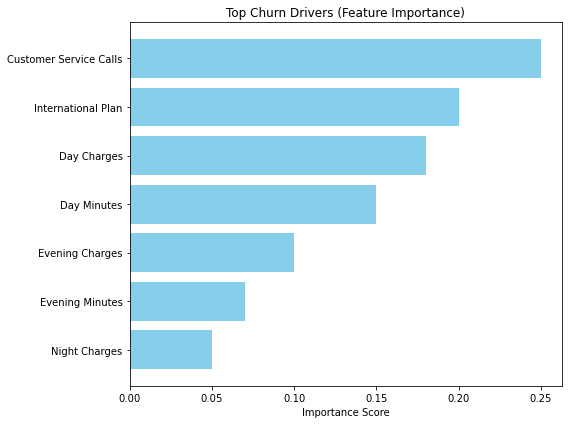

In [84]:
# Top Churn Drivers

# Example feature importance values
feature_importance = {
    "Customer Service Calls": 0.25,
    "International Plan": 0.20,
    "Day Charges": 0.18,
    "Day Minutes": 0.15,
    "Evening Charges": 0.10,
    "Evening Minutes": 0.07,
    "Night Charges": 0.05
}

# Convert the DataFrame
df_feat = pd.DataFrame(list(feature_importance.items()), 
                       columns=["Feature", "Importance"])

# Sorting by importance
df_feat = df_feat.sort_values(by="Importance", ascending=True)

# Horizontal Bar chart
plt.figure(figsize=(8,6))
plt.barh(df_feat["Feature"], df_feat["Importance"], color="skyblue")
plt.xlabel("Importance Score")
plt.title("Top Churn Drivers (Feature Importance)")
plt.tight_layout()
plt.show()


7.3 **Recommendations**

*Feature Engineering* : Consider creating new features or using feature interactions to improve machine learning model performance. (For example Customer service calls combined with tenure), additional  customer attributes like age, gender,income, occupation.

*Hyper-parameter Tuning*: Grid Search/ Random Search  could be employed to further tune hyper-parameters for Logistic Regression (C, penalty type) and Decision Tress(max,depth,min samples split, max features).

*Feature Importane*: Random Forest classifier model shows strong performance with clear interpretation of feature importance. Focus on improving features such as International plan and Customer Service Calls.

*Customer Retention Strategy* : Based on model insights, focus retention efforts on customers with high churn likelihood (identified by all the 3 models), particularly those showing frequent customer service calls and high usage of certain features i.e International Plan.


7.4 **LImitations**

This dataset has potential limitations which include :

*Class Imbalance* : The number of churned customers is much smaller than non-churned , which can affect model performance and bias predictions toward the majority class.

*Limited Time Frame*: The time frame of 9 months is limited and may not capture seasonal or long-term patterns.

*Location Bias* :
The dataset may not capture the full nationa population or capture regional variations accurately.

7.5 **Next Steps**

Suggestions to improve on the dataset include:



Adding more customer attributes:Demographics: age, gender, income, occupation.

Include Subscription details: contract type, tenure, plan changes in the dataset.

Service quality metrics: dropped calls, network coverage, complaint history.

Increasing dataset size and diversity:
Collect data across multiple time periods and regions to improve model generalization.

Balance the dataset better between churned and non-churned customers to reduce class imbalance.

